In [4]:
%matplotlib widget

In [5]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [6]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     377   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


In [7]:
image_cut = image[52:172, 0:1890]
image_error_cut = image_error[52:172, 0:1890]

Text(0.5, 0, 'wavelenght')

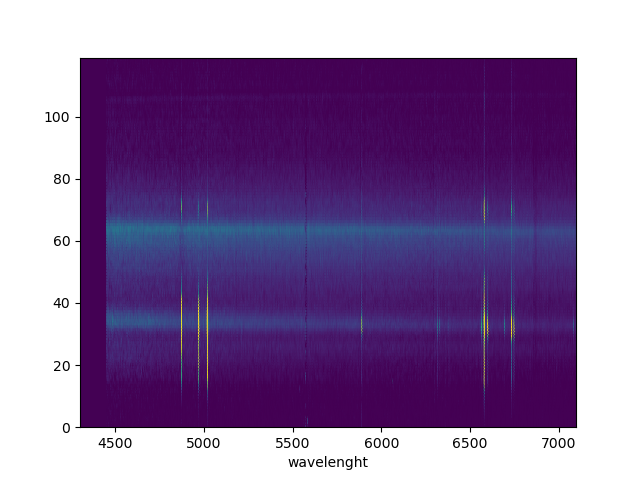

In [8]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [9]:
z = 0.00309
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Text(0.5, 1.0, 'H$\\alpha$')

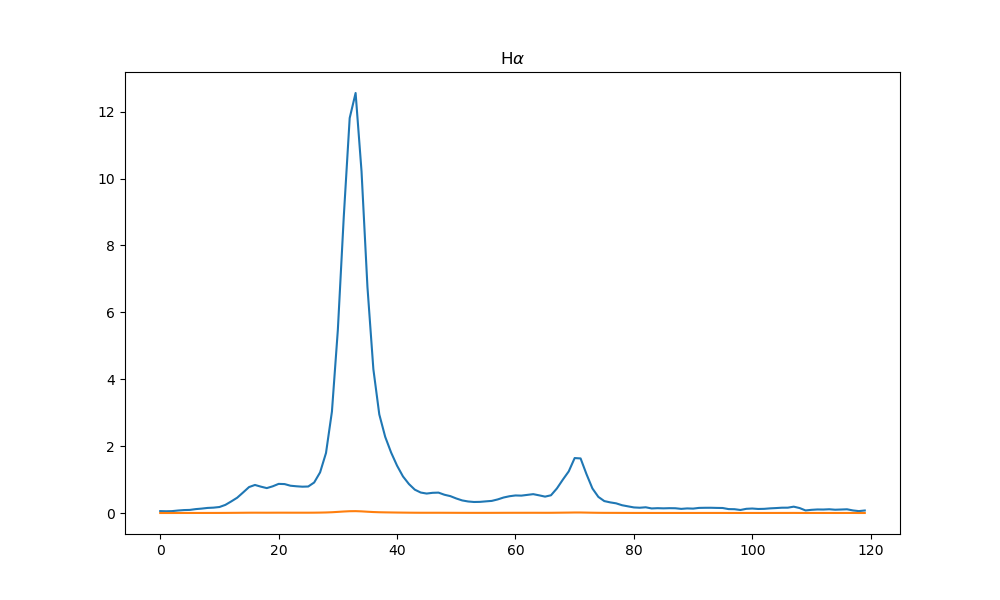

In [10]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')
#fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)

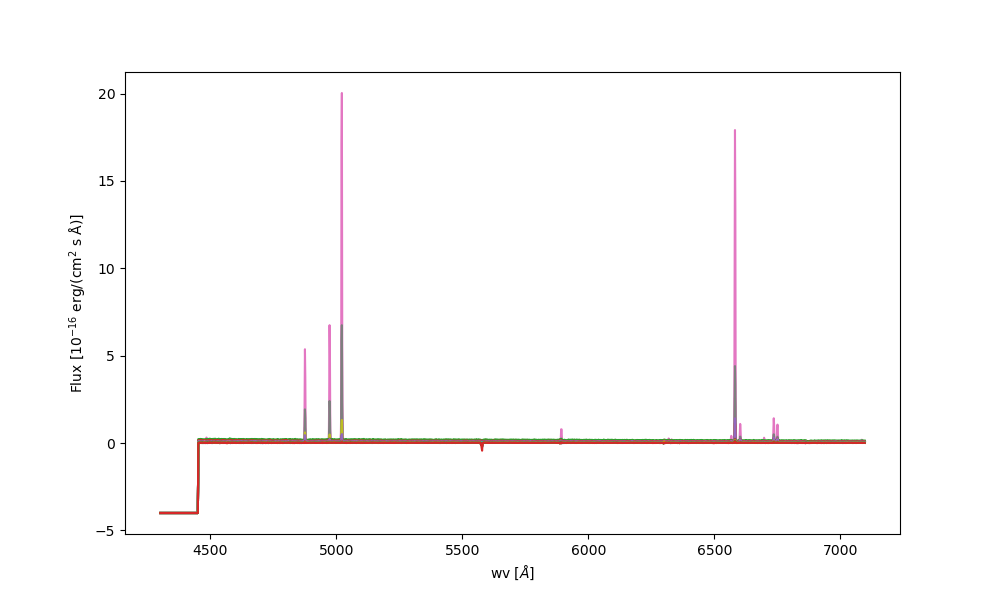

In [11]:
def extraction(x_axes, x_min, x_max, image_cut, image_error_cut):
    mask = (x_axes > x_min)*(x_axes < x_max)
    spectrum = np.sum(image_cut[mask, :], axis = 0)
    spectrum_err = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0))
    return spectrum, spectrum_err

os.makedirs('24ext', exist_ok=True)

spectra =  np.zeros((24, image_cut.shape[1]))
spectra_err = np.zeros((24, image_error_cut.shape[1]))
plt.figure(figsize=(10, 6))
for i in range(24):
    x_min = i * 5
    x_max = x_min + 5
    spectra[i], spectra_err[i] = extraction(x_axes, x_min, x_max, image_cut, image_error_cut)

    plt.plot(wv, spectra[i], label = f'spectrum {i+1}')
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra[i].reshape(-1, 1), spectra_err[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('24ext', f'Spectrum_{i+1}.txt')  # Salva come spectrum_1.txt ... spectrum_20.txt
    np.savetxt(filename, spectrum_table)

## S/N continuum

In [13]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5100)*(wv < 5400)
mask_continuum_3 = (wv > 5910)*(wv < 6210)

# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(24):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra[i, mask_continuum_1])
    noise_1 = np.std(spectra[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra[i, mask_continuum_2])
    noise_2 = np.std(spectra[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra[i, mask_continuum_3])
    noise_3 = np.std(spectra[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
    
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(24)]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
os.path.join('24ext', 'SNR_24ext_continuum.csv')
df_path_snr = os.path.join('24ext', 'SNR_24ext_continuum.csv')
df_path_signal = os.path.join('24ext', 'Signal_24ext_continuum.csv')
df_path_noise = os.path.join('24ext', 'Noise_24ext_continuum.csv')
df_path_combined = os.path.join('24ext', 'Combined_24ext_continuum.csv')
# Assicurati che la directory esista
os.makedirs('24ext', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    1.647261    2.213475    3.021752    5.248665    6.896675   
Continuum_2    2.779231    2.950632    4.123533    6.662886    8.374123   
Continuum_3    2.886493    3.021048    3.746621    5.515041    8.191752   

             Spectrum_6  Spectrum_7  Spectrum_8  Spectrum_9  Spectrum_10  ...  \
Continuum_1    7.557814   12.242142    9.931090    8.979596    10.337135  ...   
Continuum_2   10.233102   13.545888   11.001459   10.585393    11.449794  ...   
Continuum_3    8.975344   12.852249   11.938716   10.900801    13.262643  ...   

             Spectrum_15  Spectrum_16  Spectrum_17  Spectrum_18  Spectrum_19  \
Continuum_1     9.729196     7.817349     6.305514     5.197351     5.653591   
Continuum_2    12.869550    10.442502     8.090928     6.296871     6.390991   
Continuum_3    13.990346    10.697995     8.655015     6.672568     6.661430   

             Spectrum_20  Spectrum_21 

## Redshift

In [14]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Spettro 1
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 22
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
  4876.45999999983   emission               286
 4972.659999999802   emission               351
 5021.499999999787   emission               384
 5585.379999999621   emission               765
 5888.779999999531   emission               970
 6581.419999999327   emission              1438
 6736.819999999281   emission              1543
 6751.619999999277   emission              1553
 4578.979999999918 absorption                85
 4700.339999999882 absorption               167
  4707.73999999988 absorption               172
 4729.939999999873 absorption               187
 5141.379999999752 absorption               465
5471.4199999996545 absorption               688
 5573.539999999624 absorption               757
 5577.979999999623 absorption               760
5891.7399999995305


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 24
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 17
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
  4874.97999999983   emission               285
 5021.499999999787   emission               384
 6581.419999999327   emission              1438
 6735.339999999282   emission              1542
 6750.139999999277   emission              1552
 5577.979999999623 absorption               760
 5885.819999999532 absorption               968
5891.7399999995305 absorption               972
 6116.699999999464 absorption              1124
 6255.819999999423 absorption              1218
 6303.179999999409 absorption              1250
 6394.939999999382 absorption              1312
 6500.019999999351 absorption              1383
 6554.779999999335 absorption              1420
 6588.819999999325 absorption              1443
 6702.779999999291 absorption              1520
 6924.77999999922

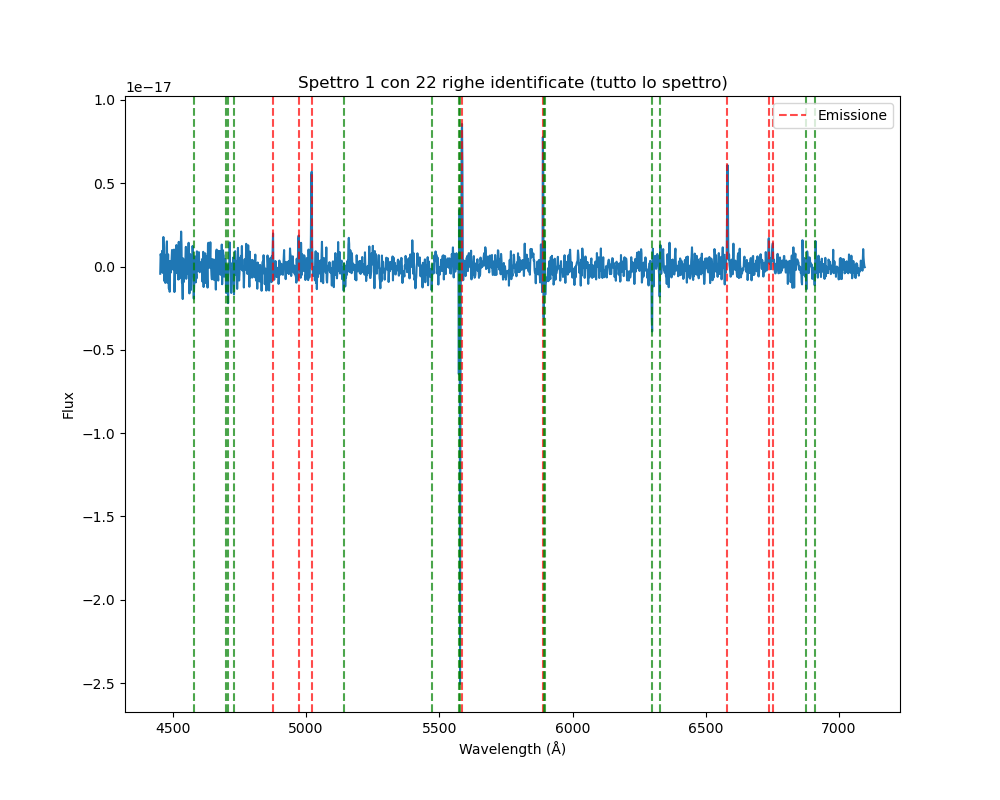

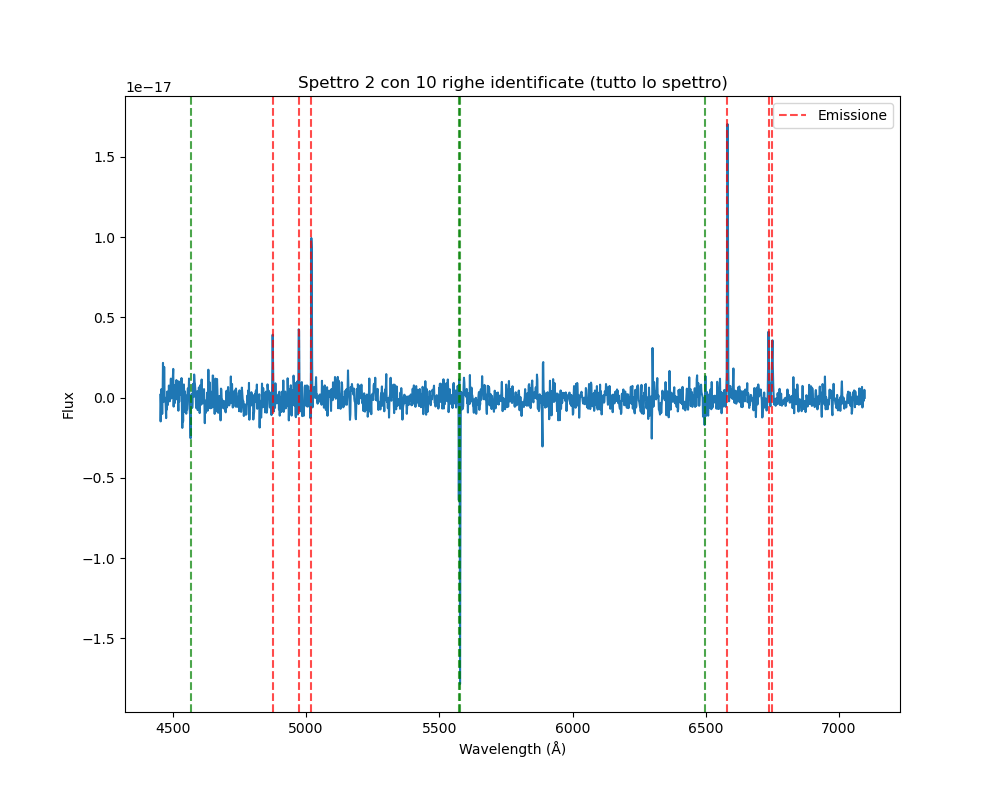

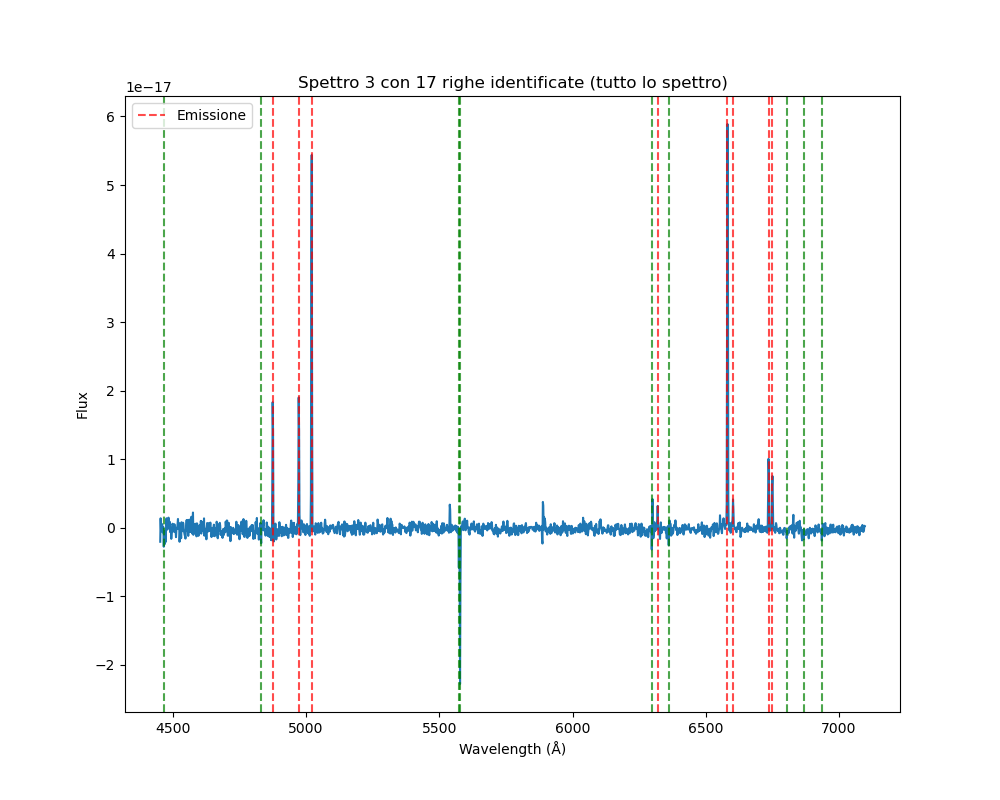

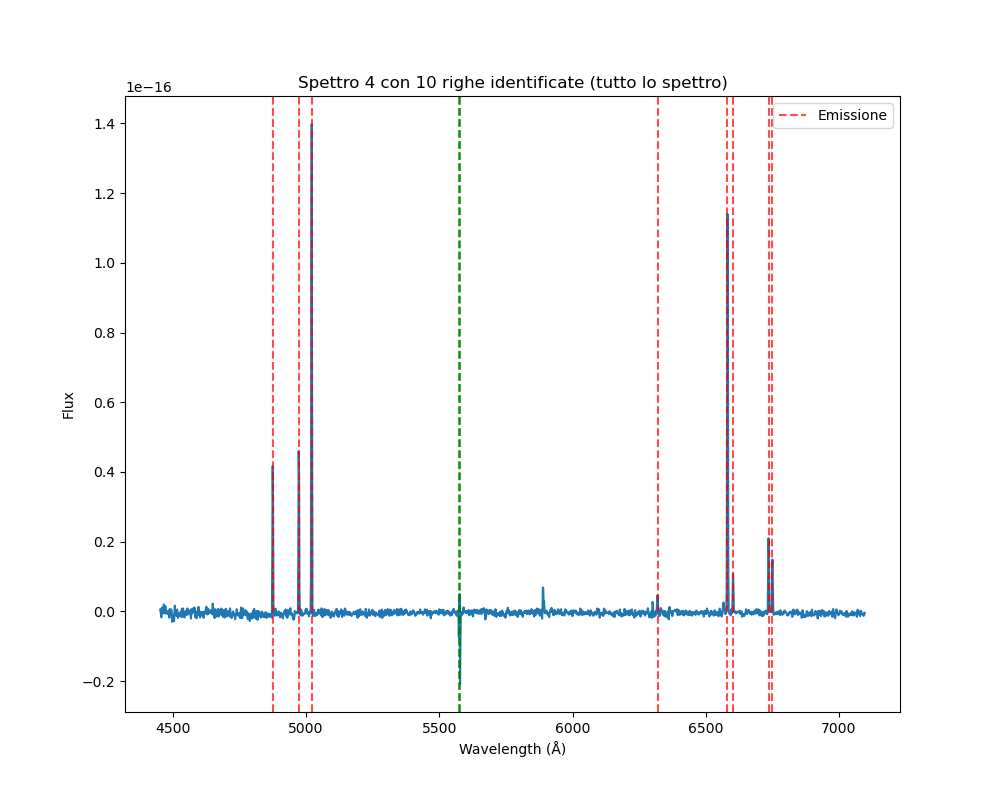

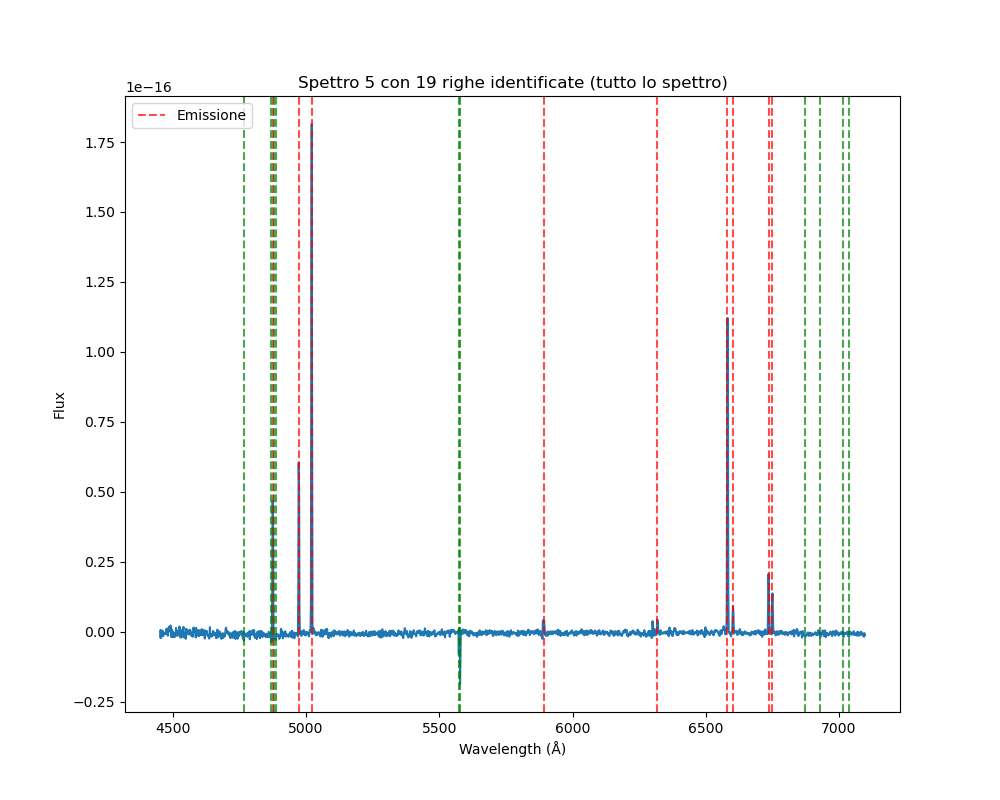

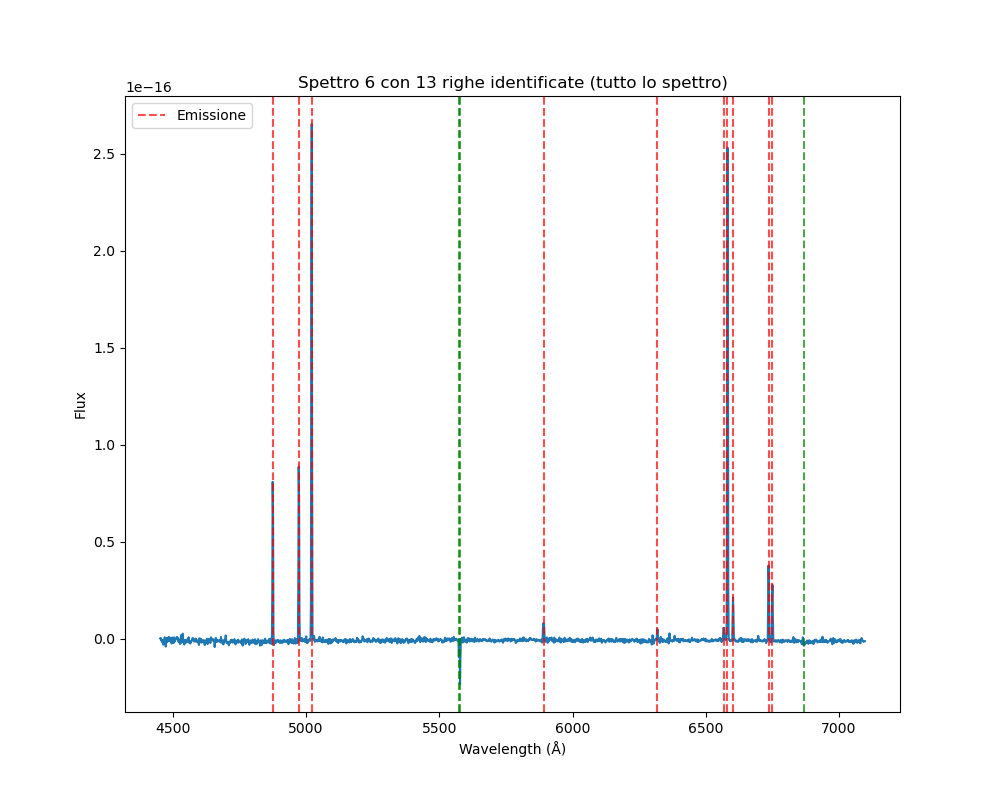

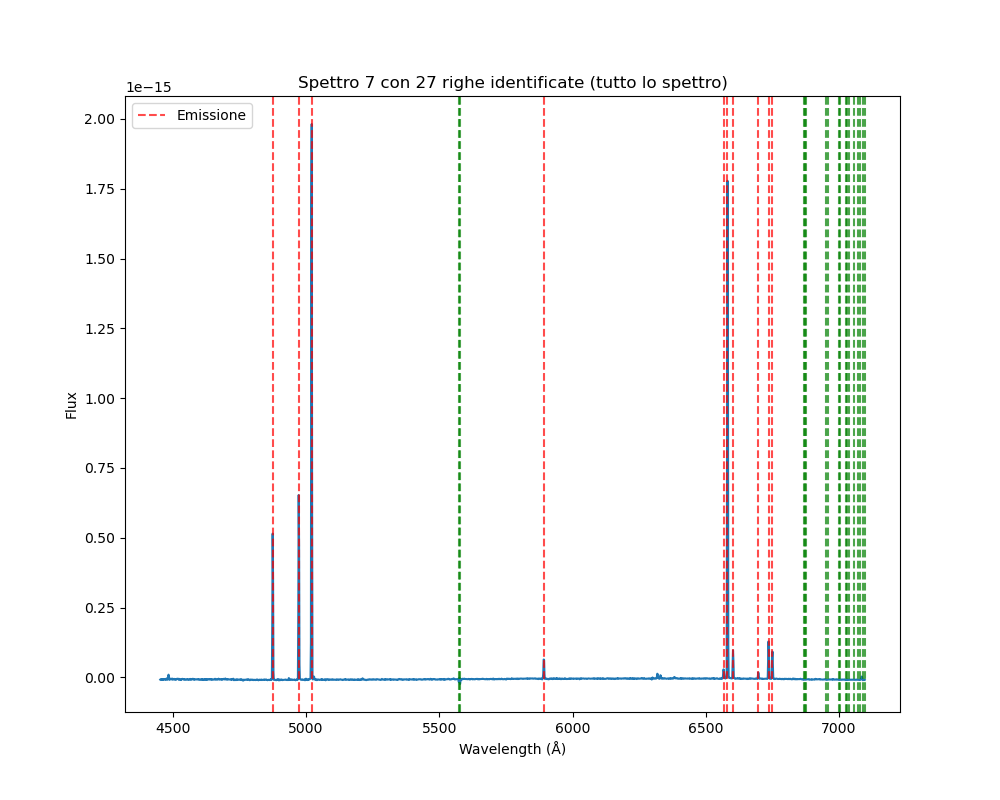

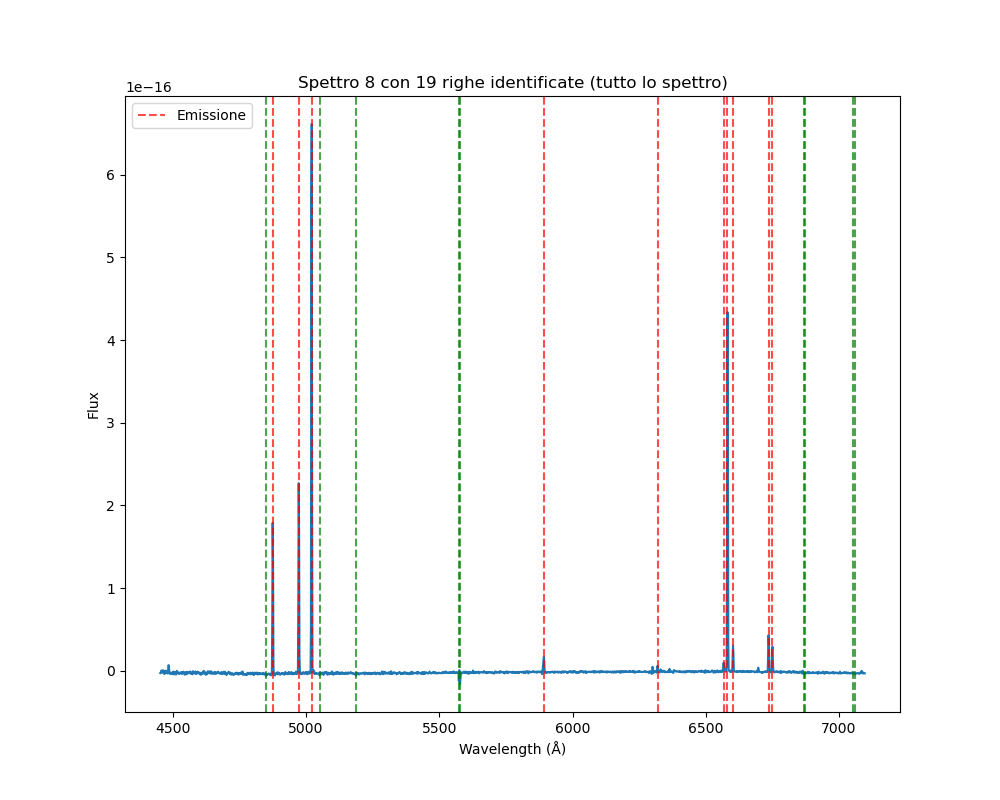

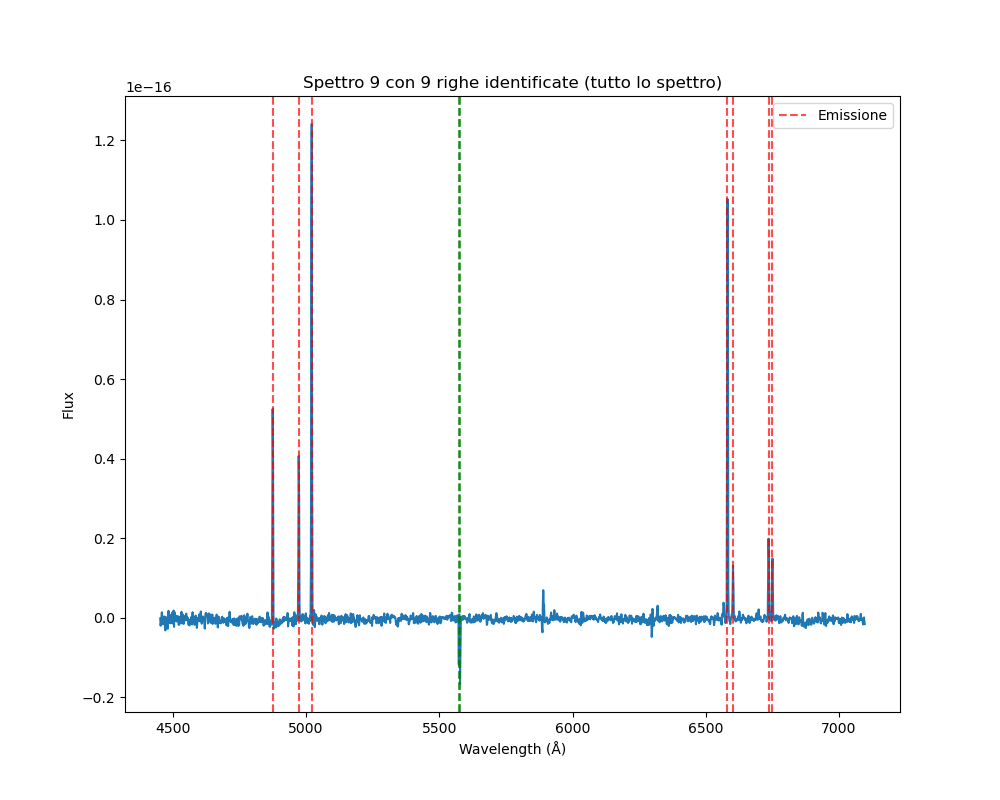

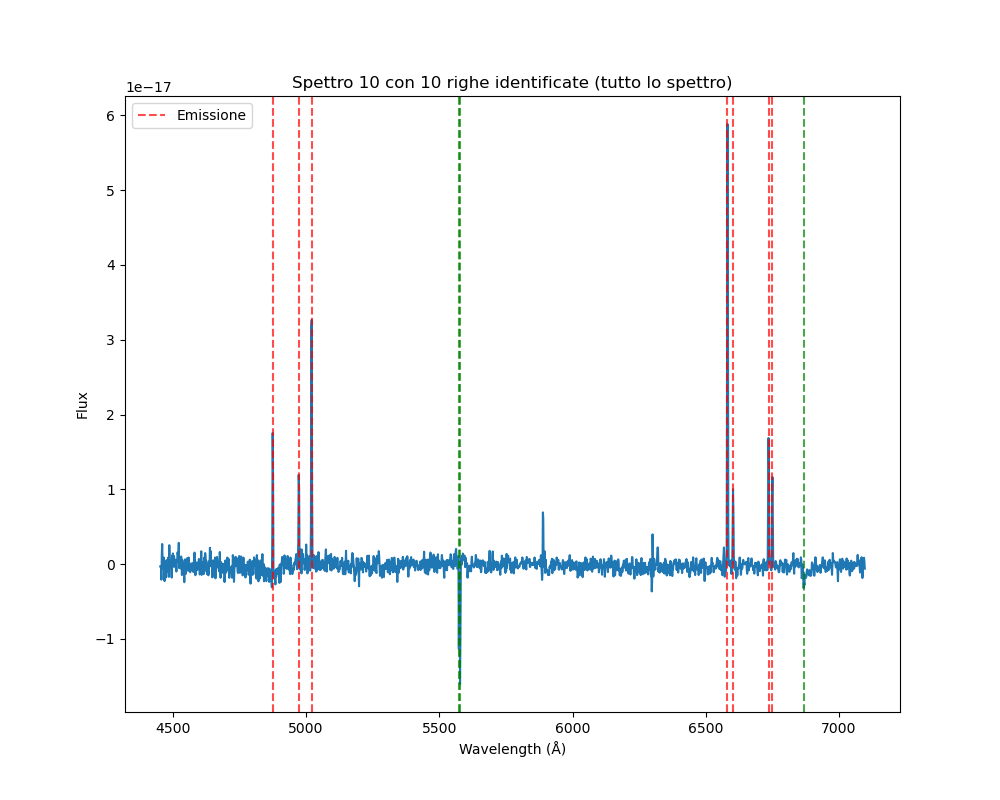

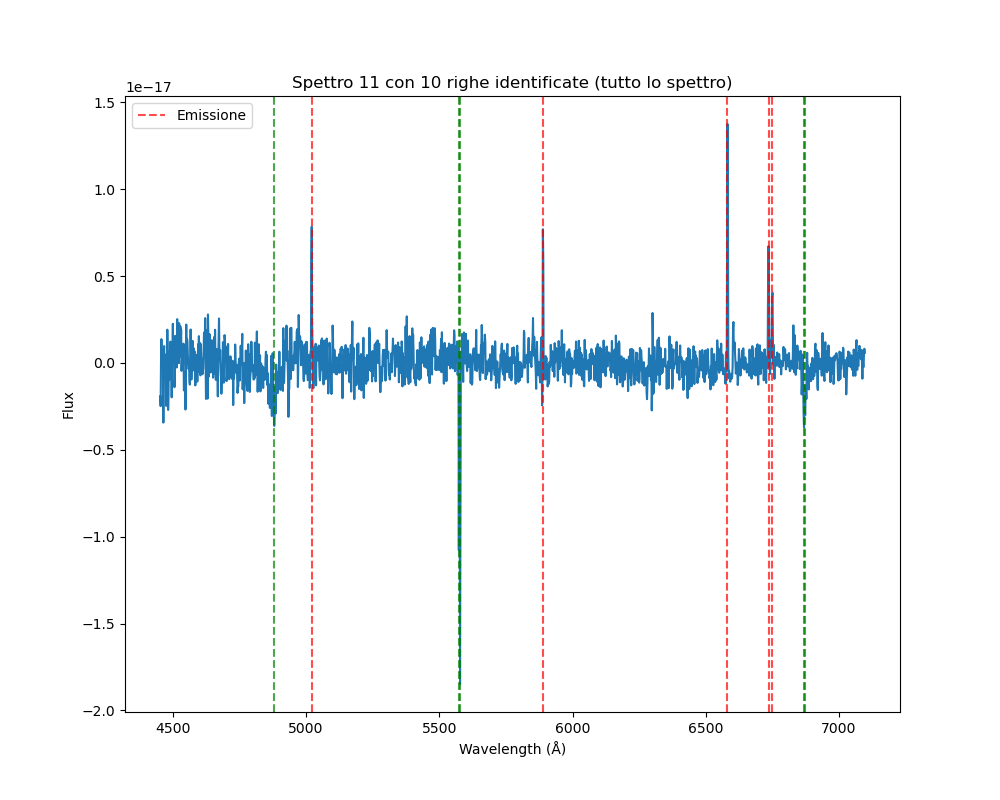

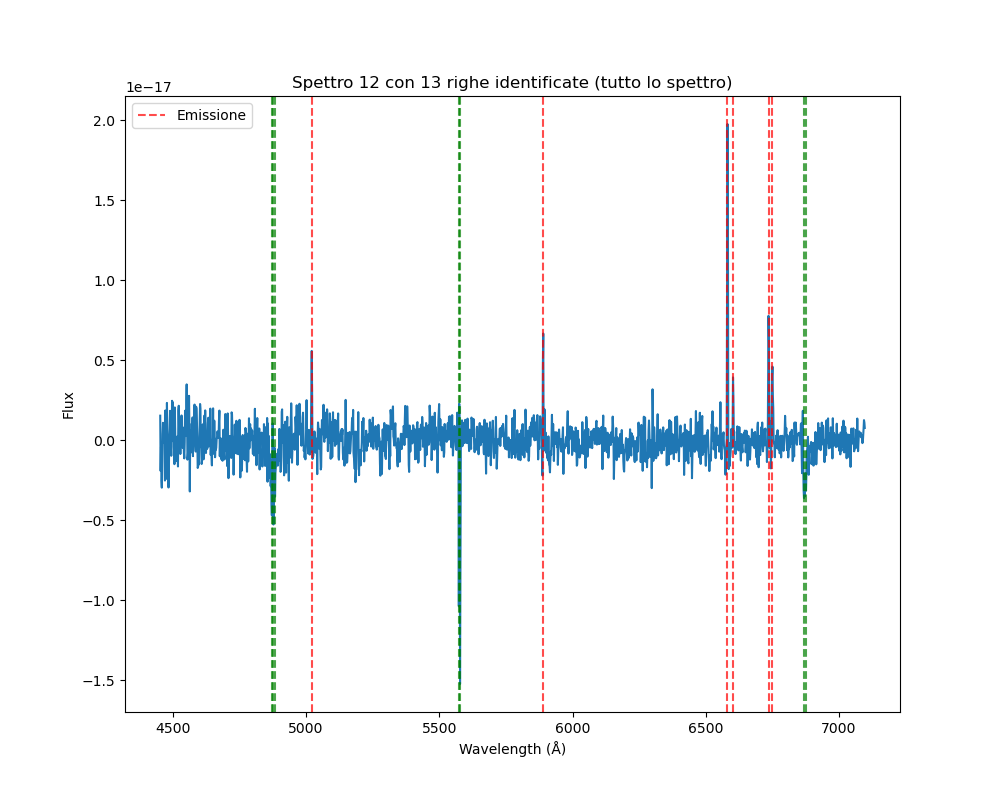

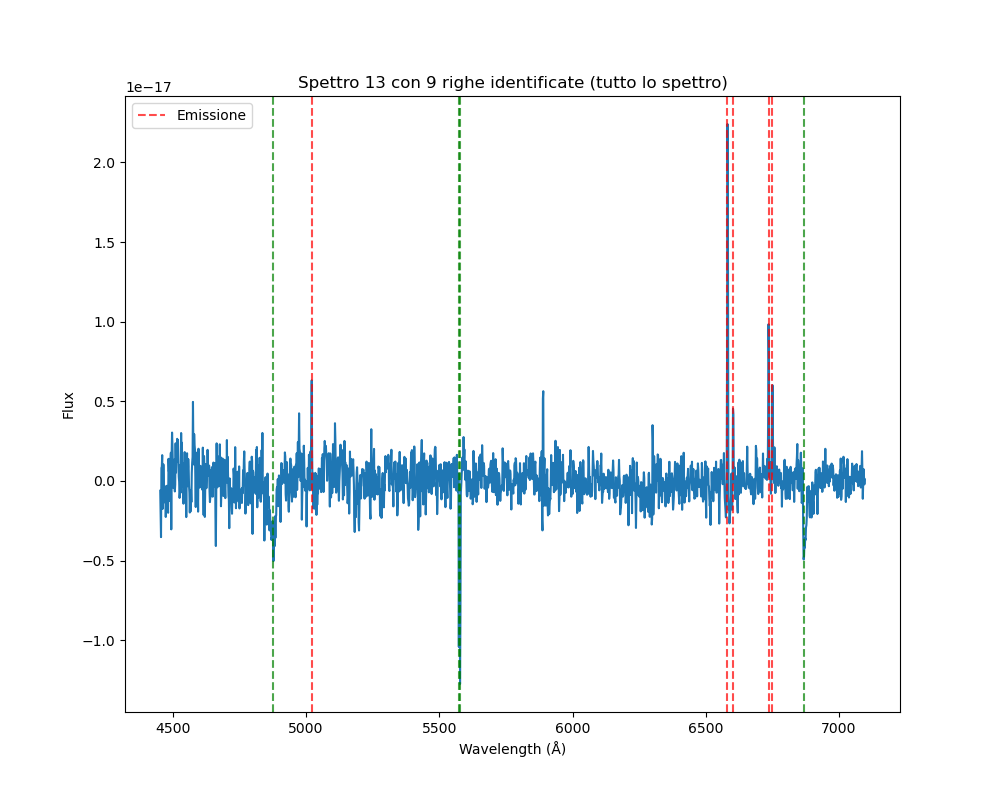

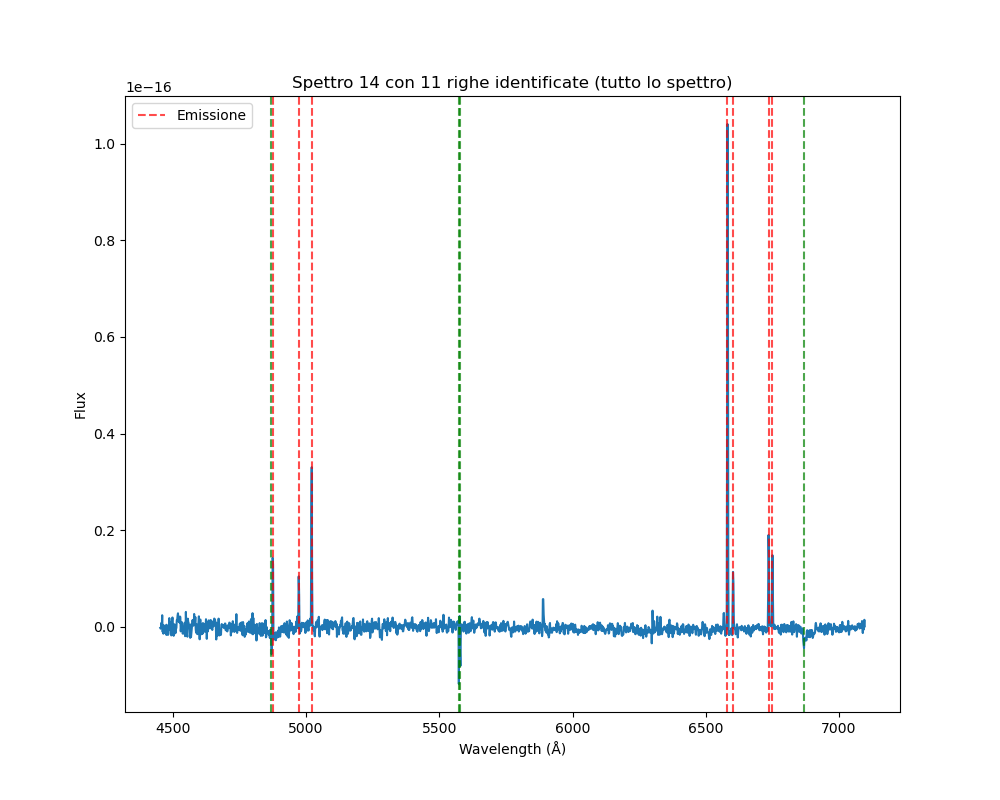

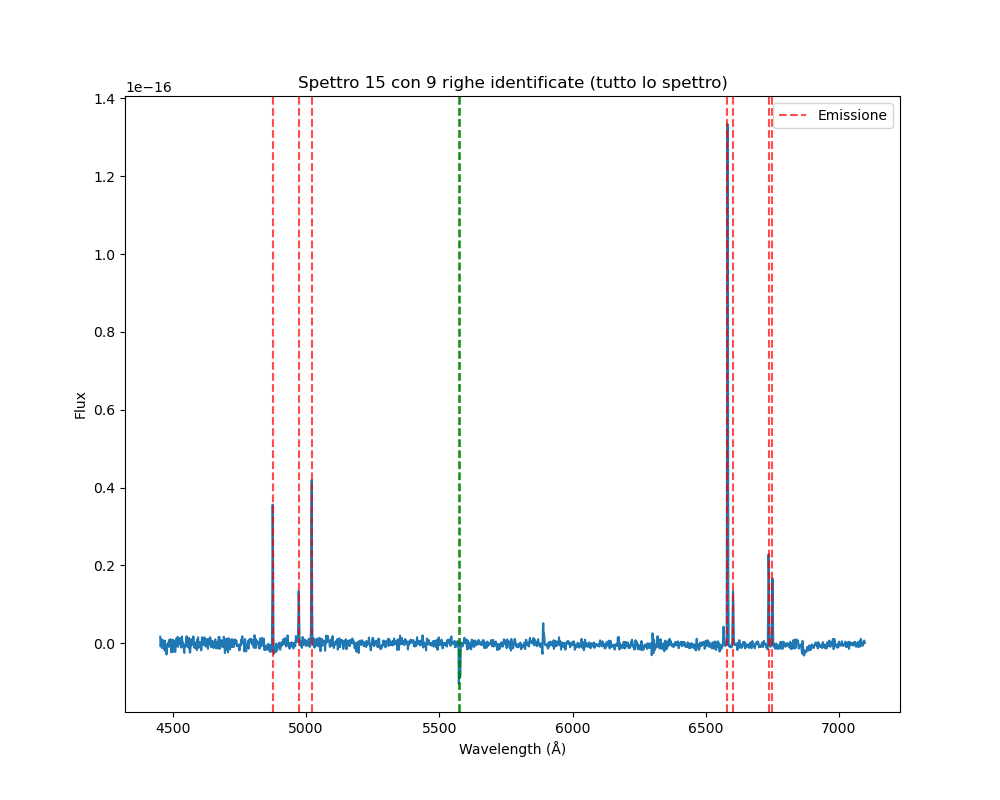

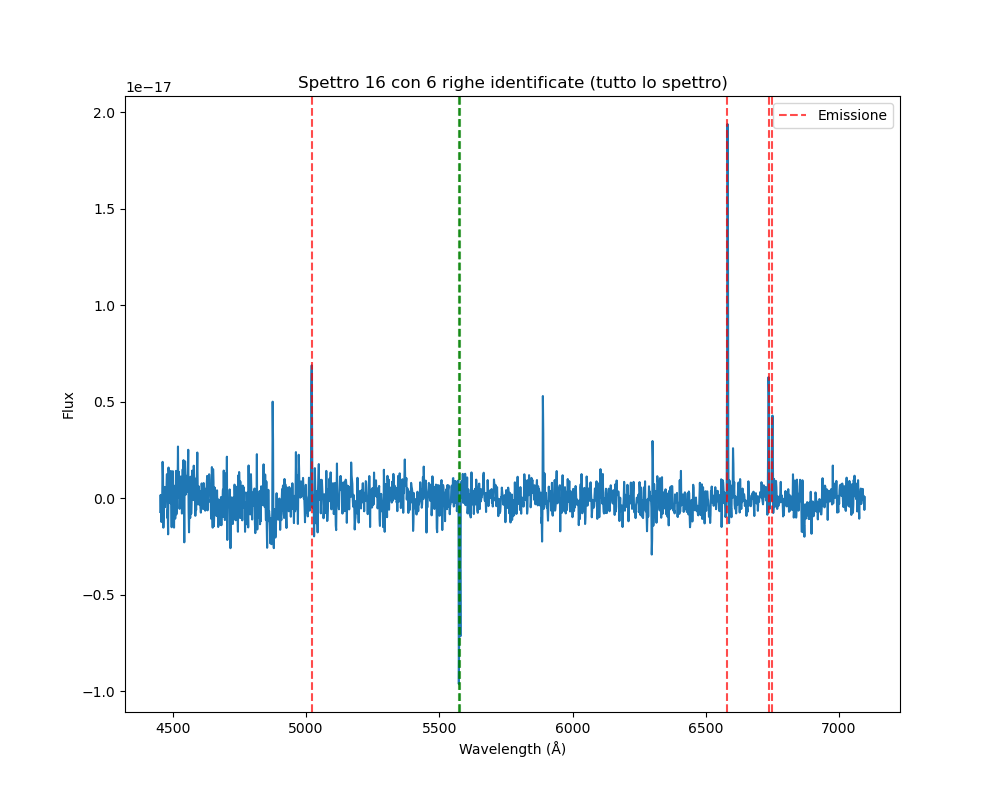

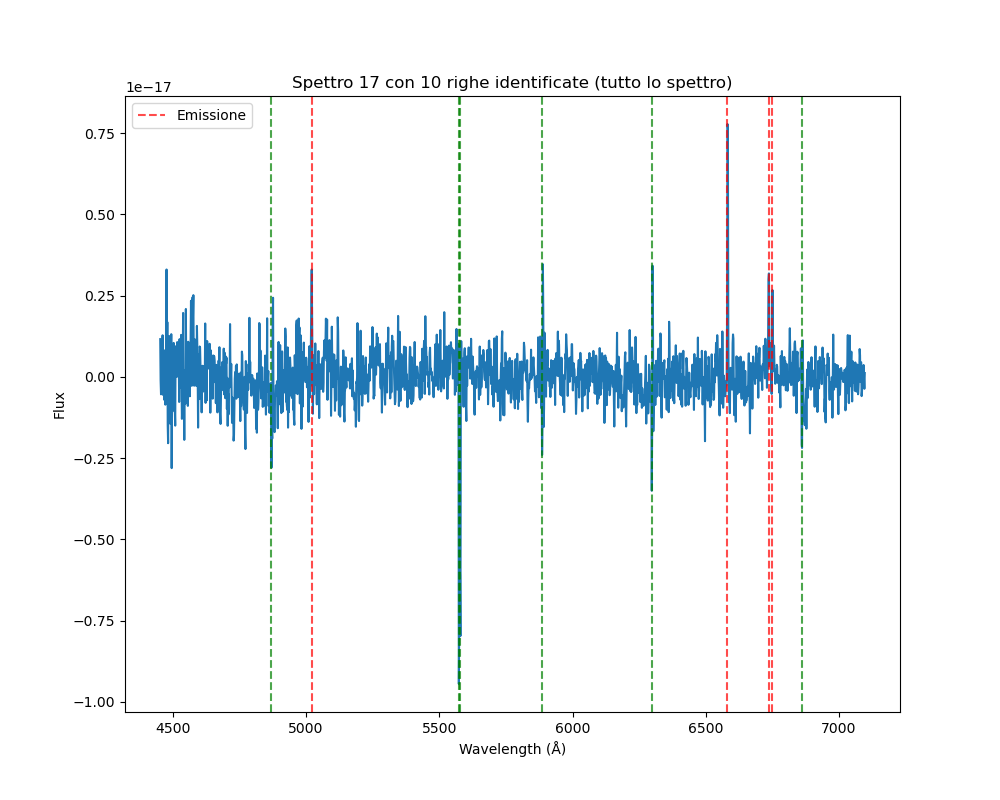

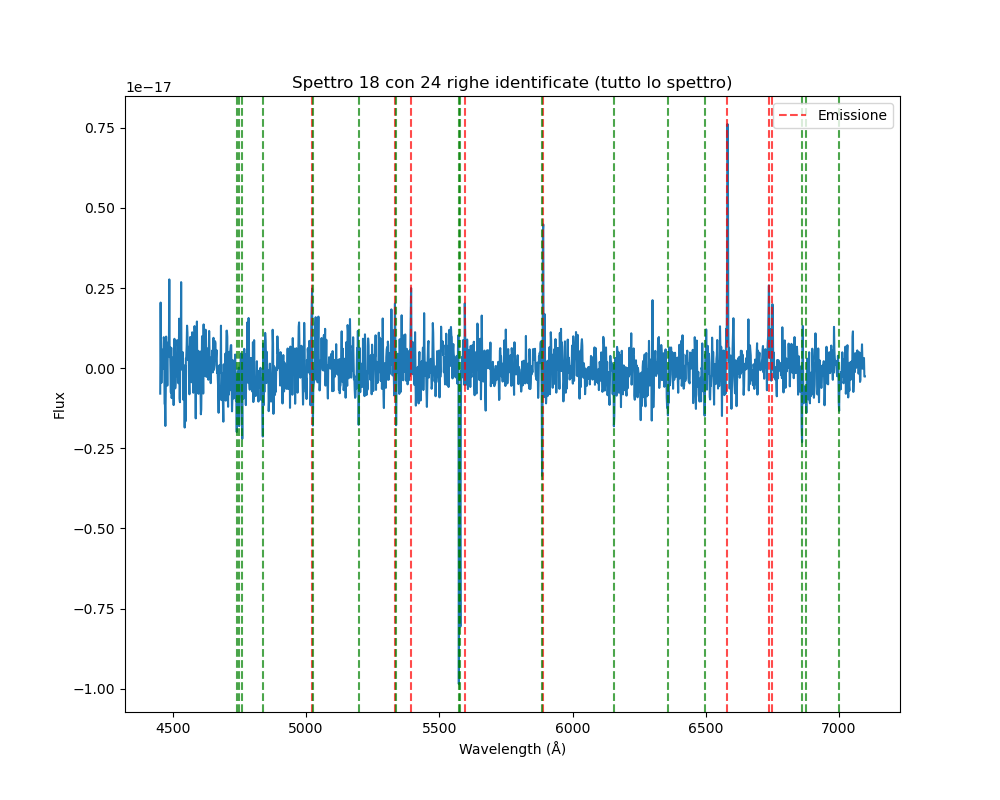

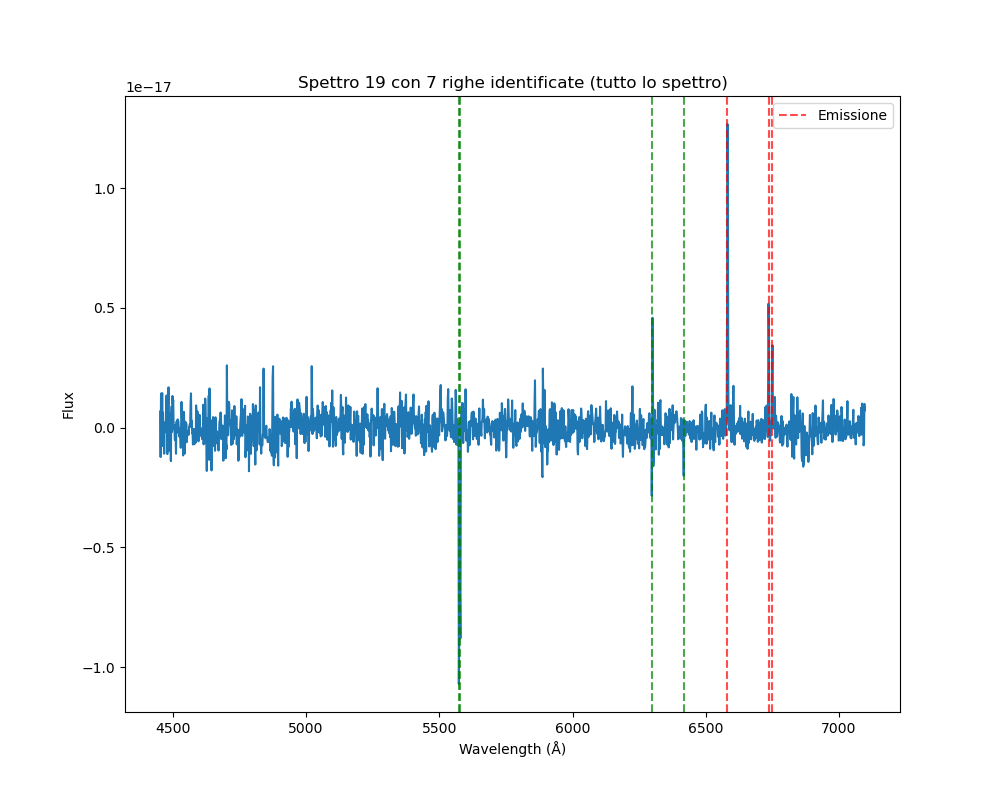

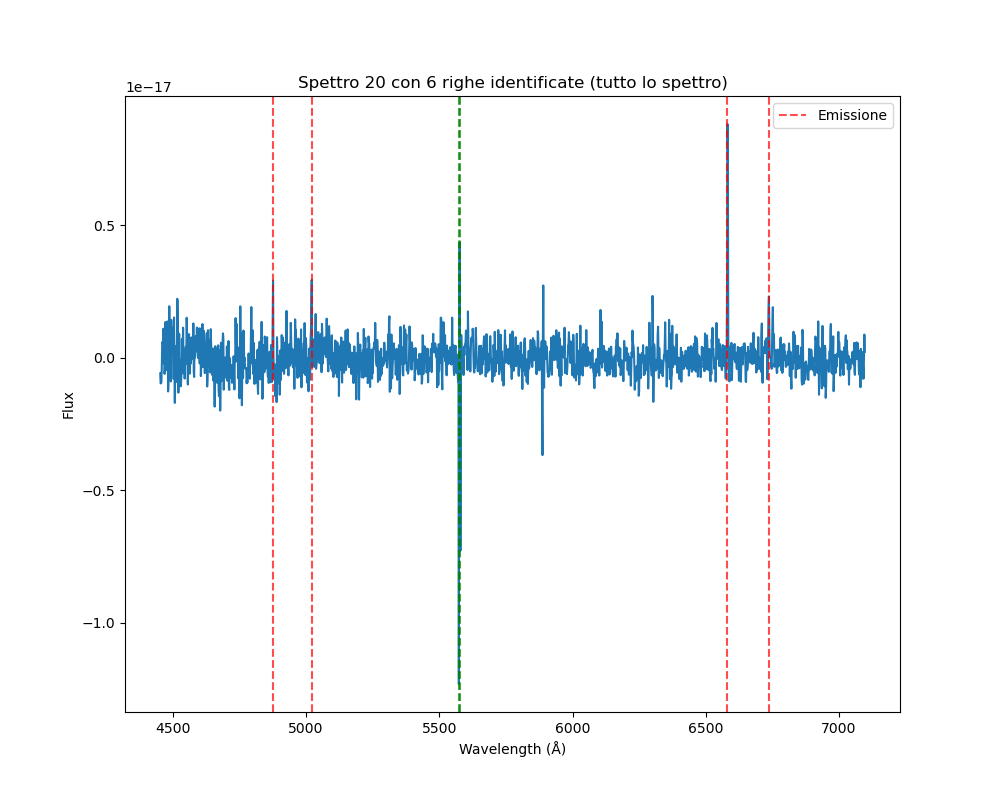

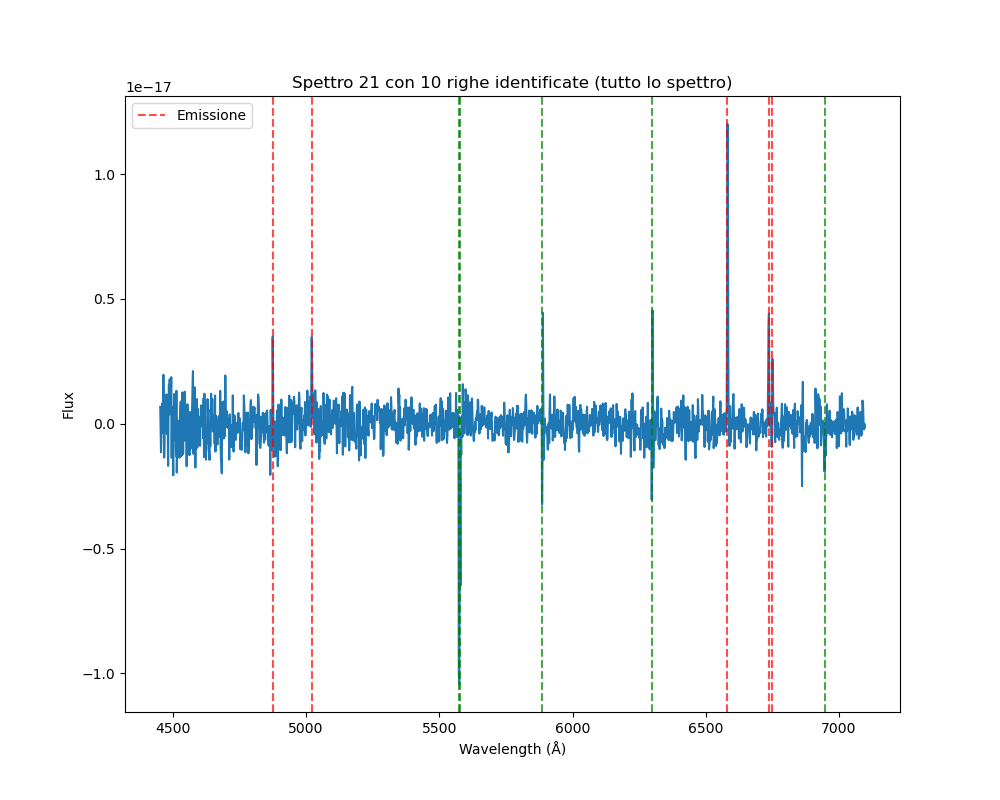

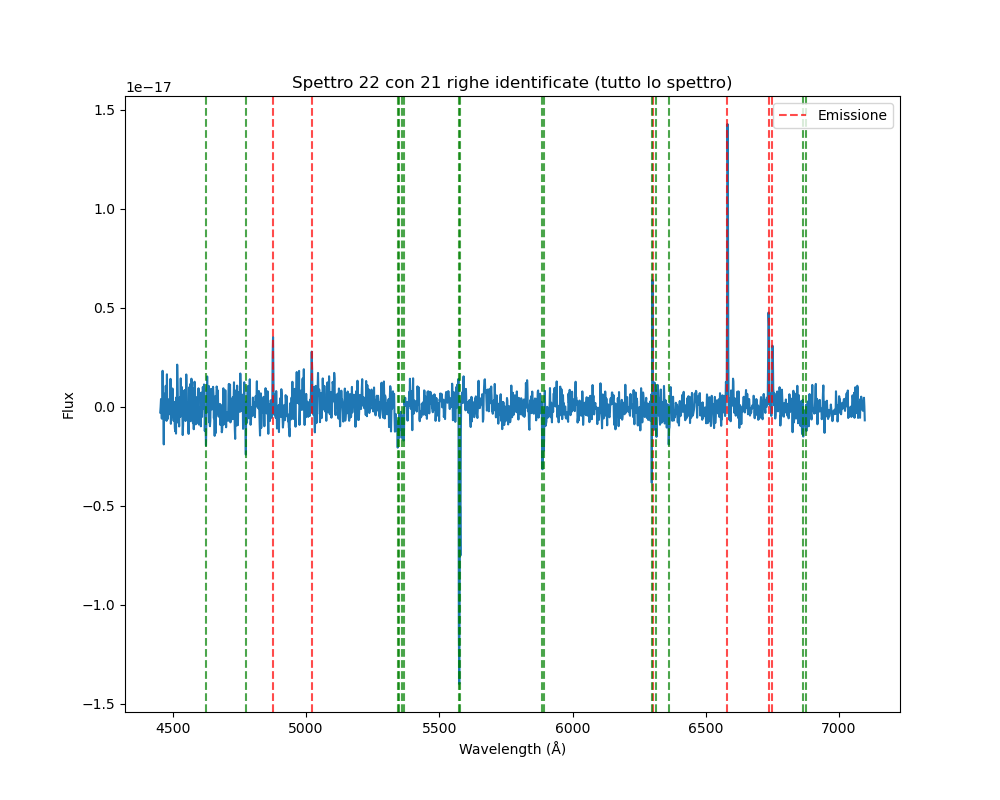

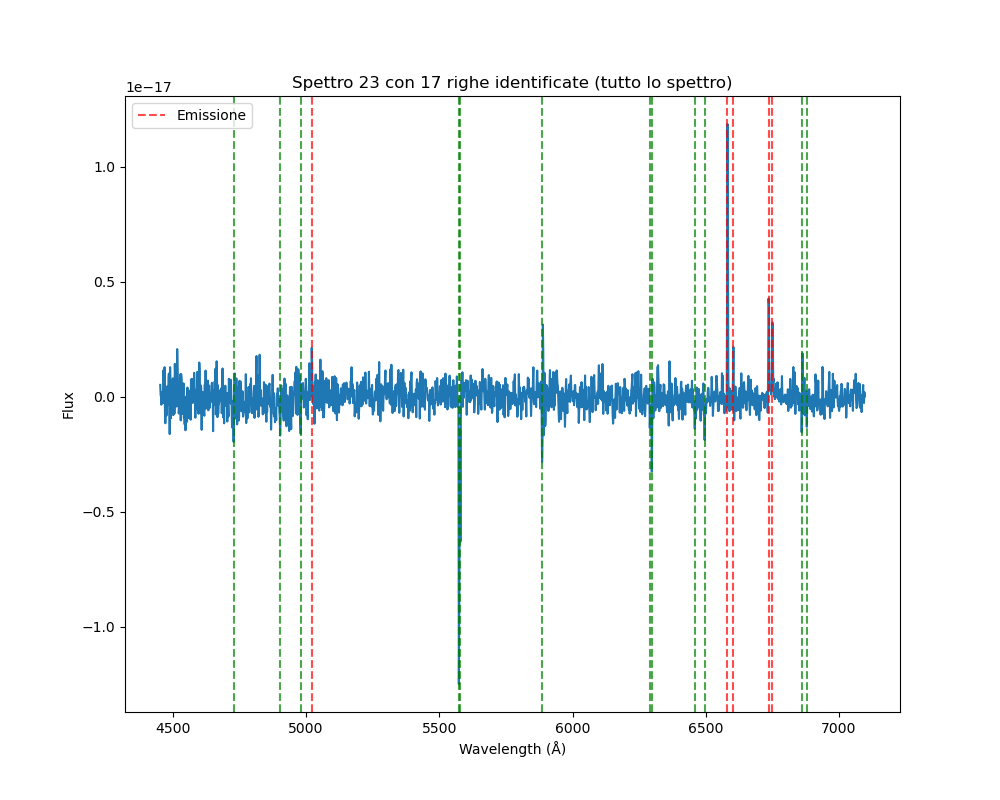

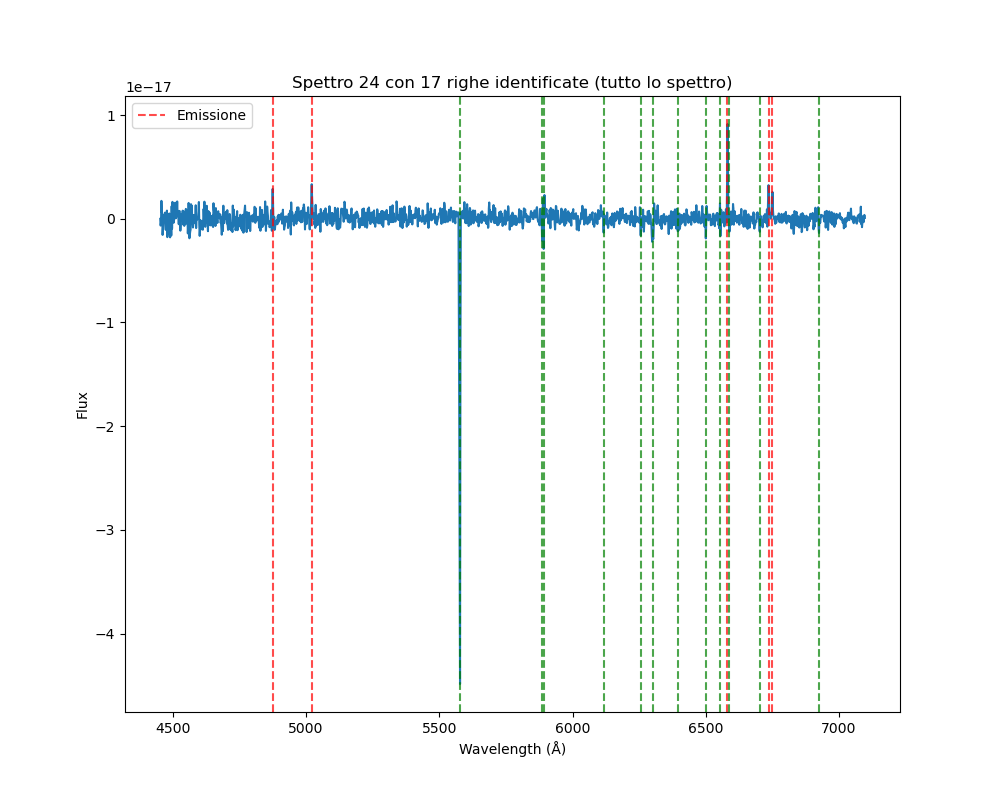

In [37]:
all_lines = []
noise_factor = [3, 4, 4, 5, 4, 7, 15, 7, 7, 6, 4, 4, 5, 6, 7, 6, 4, 3, 4, 4, 4, 3, 3, 3]

# Filtra per lunghezze d'onda > 4451 Å
wv_mask = wv > 4452
wv_filtered = wv[wv_mask]

for i in range(24):
    # Applica il filtro anche agli spettri
    spectra_filtered = spectra[i][wv_mask]
    spectra_err_filtered = spectra_err[i][wv_mask]
    
    # Usa lo spettro filtrato per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux = spectra_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv_filtered * u.Angstrom)
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    
    # Crea lo spettro per TUTTO il range filtrato (senza ritagliare i bordi)
    spectrum_no_continuum_full = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux=flux_continuum_subtracted,
        uncertainty=StdDevUncertainty(spectra_err_filtered * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe su TUTTO lo spettro filtrato (senza escludere i bordi)
    lines = find_lines_threshold(spectrum_no_continuum_full, noise_factor = noise_factor[i])
    print('Spettro', i+1)
    print(f"Numero di righe trovate (tutto lo spettro, wv > 4451 Å): {len(lines)}")
    print(lines)
    
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv_filtered, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            line_idx = np.argmin(np.abs(wv_filtered - line_pos.value))
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[line_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")
    
    ax3.legend()
    ax3.set_title(f"Spettro {i+1} con {len(lines)} righe identificate (tutto lo spettro)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [44]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6
l_OI = 6300.3

lines_1 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_SII_1, l_SII_2]
lines_2 = [l_HB, l_OIII_1,l_OIII_2, l_HA, l_SII_1, l_SII_2]
lines_3 = [l_HB, l_OIII_1, l_OIII_2, l_OI, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_4 = [l_HB, l_OIII_1, l_OIII_2, l_OI, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_5 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_OI, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_6 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_OI, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_7 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_8 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_OI, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_9 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_10 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_11 = [l_OIII_2, l_HA, l_SII_1, l_SII_2]
lines_12 = [l_OIII_2, l_He_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_13 = [l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_14 = [l_HB, l_OIII_1,l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_15 = [l_HB, l_OIII_1,l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_16 = [l_OIII_2, l_HA, l_SII_1, l_SII_2]
lines_17 = [l_OIII_2, l_HA, l_SII_1, l_SII_2]
lines_18 = [l_OIII_2, l_HA, l_SII_1, l_SII_2]
lines_19 = [l_HA, l_SII_1, l_SII_2]
lines_20 = [l_HB, l_OIII_2, l_HA, l_SII_1]
lines_21 = [l_HB, l_OIII_2, l_HA, l_SII_1, l_SII_2]
lines_22 = [l_HB, l_OIII_2, l_HA, l_SII_1, l_SII_2]
lines_23 = [l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_24 = [l_HB, l_OIII_2, l_HA, l_SII_1, l_SII_2]

lines_spectrum_1 = [4876.45999999983, 4972.659999999802, 5021.499999999787, 6581.419999999327, 6736.819999999281, 6751.619999999277]
lines_spectrum_2 = all_lines[1]['line_center']
lines_spectrum_3 = all_lines[2]['line_center']
lines_spectrum_4 = all_lines[3]['line_center']
lines_spectrum_5 = all_lines[4]['line_center']
lines_spectrum_6 = all_lines[5]['line_center']
lines_spectrum_7 = [4874.97999999983, 4972.659999999802, 5021.499999999787, 5891.7399999995305,  6566.619999999331, 6581.419999999327,  6602.139999999321,  6735.339999999282,  6750.139999999277]
lines_spectrum_8 = all_lines[7]['line_center']
lines_spectrum_9 = all_lines[8]['line_center']
lines_spectrum_10 = all_lines[9]['line_center']
lines_spectrum_11 = [5021.499999999787, 6581.419999999327, 6735.339999999282, 6750.139999999277]
lines_spectrum_12 = all_lines[11]['line_center'] 
lines_spectrum_13 = all_lines[12]['line_center'] 
lines_spectrum_14 = all_lines[13]['line_center'] 
lines_spectrum_15 = all_lines[14]['line_center']
lines_spectrum_16 = all_lines[15]['line_center']
lines_spectrum_17 = all_lines[16]['line_center']
lines_spectrum_18 = [5022.979999999787, 6581.419999999327, 6736.819999999281, 6750.139999999277] 
lines_spectrum_19 = all_lines[18]['line_center']
lines_spectrum_20 = all_lines[19]['line_center']
lines_spectrum_21 = all_lines[20]['line_center']
lines_spectrum_22 = [4876.45999999983, 5021.499999999787, 6581.419999999327, 6735.339999999282, 6750.139999999277]
lines_spectrum_23 = all_lines[22]['line_center']
lines_spectrum_24 = all_lines[23]['line_center']

def redshift(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i].value / lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
def redshift_hand(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i]/ lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
z_1_mean, z_1_std = redshift_hand(lines_1, lines_spectrum_1)
z_2_mean, z_2_std = redshift(lines_2, lines_spectrum_2)
z_3_mean, z_3_std = redshift(lines_3, lines_spectrum_3)
z_4_mean, z_4_std = redshift(lines_4, lines_spectrum_4)
z_5_mean, z_5_std = redshift(lines_5, lines_spectrum_5) 
z_6_mean, z_6_std = redshift(lines_6, lines_spectrum_6) 
z_7_mean, z_7_std = redshift_hand(lines_7, lines_spectrum_7) 
z_8_mean, z_8_std = redshift(lines_8, lines_spectrum_8) 
z_9_mean, z_9_std = redshift(lines_9, lines_spectrum_9) 
z_10_mean, z_10_std = redshift(lines_10, lines_spectrum_10) 
z_11_mean, z_11_std = redshift_hand(lines_11, lines_spectrum_11) 
z_12_mean, z_12_std = redshift(lines_12, lines_spectrum_12) 
z_13_mean, z_13_std = redshift(lines_13, lines_spectrum_13) 
z_14_mean, z_14_std = redshift(lines_14, lines_spectrum_14) 
z_15_mean, z_15_std = redshift(lines_15, lines_spectrum_15)
z_16_mean, z_16_std = redshift(lines_16, lines_spectrum_16) 
z_17_mean, z_17_std = redshift(lines_17, lines_spectrum_17) 
z_18_mean, z_18_std = redshift_hand(lines_18, lines_spectrum_18)
z_19_mean, z_19_std = redshift(lines_19, lines_spectrum_19) 
z_20_mean, z_20_std = redshift(lines_20, lines_spectrum_20) 
z_21_mean, z_21_std = redshift(lines_21, lines_spectrum_21) 
z_22_mean, z_22_std = redshift_hand(lines_22, lines_spectrum_22) 
z_23_mean, z_23_std = redshift(lines_23, lines_spectrum_23) 
z_24_mean, z_24_std = redshift(lines_24, lines_spectrum_24) 

z = [z_1_mean, z_2_mean, z_3_mean, z_4_mean, z_5_mean, z_6_mean, z_7_mean, z_8_mean, z_9_mean, z_10_mean, z_11_mean, z_12_mean, z_13_mean, z_14_mean, z_15_mean, z_16_mean, z_17_mean, z_18_mean, z_19_mean, z_20_mean, z_21_mean, z_22_mean, z_23_mean, z_24_mean]
z_err =[z_1_std, z_2_std, z_3_std, z_4_std, z_5_std, z_6_std, z_7_std, z_8_std, z_9_std, z_10_std, z_11_std, z_12_std, z_13_std, z_14_std, z_15_std, z_16_std, z_17_std, z_18_std, z_19_std, z_20_std, z_21_std, z_22_std, z_23_std, z_24_std]

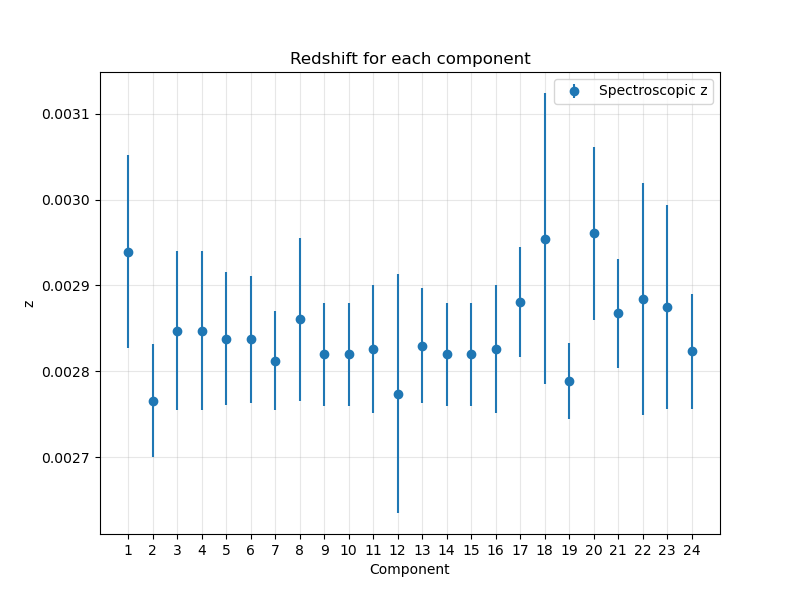

In [45]:
plt.figure(figsize=(8, 6))
comp = np.arange(1, 25, 1)
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
#plt.axhline(0.01505 , color = 'red', label = 'Tabulated z')
plt.title('Redshift for each component')
plt.legend()
plt.savefig('Redshift_grad', bbox_inches='tight')
plt.grid(alpha = 0.3)

red_table = np.column_stack((z, z_err))
np.savetxt('redshift_grad.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [46]:
def SNR_line(wv, wv_line, spectrum): 
    left_region = (wv > wv_line-15)*(wv < wv_line-5) 
    right_region = (wv > wv_line+5)*(wv < wv_line+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectrum[mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectrum):
    
    left_region = (wv > OIII_1-15)*(wv < OIII_1-5) 
    right_region = (wv > OIII_2+5)*(wv < OIII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectrum):
    
    left_region = (wv > SII_1-15)*(wv < SII_1-5) 
    right_region = (wv > SII_2+5)*(wv < SII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectrum):
    
    left_region = (wv > NII_1-15)*(wv < NII_1-5) 
    right_region = (wv > NII_2+5)*(wv < NII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def save_spectral_data(snr, signal, noise, line_name, output_dir='24ext', num_spectra=24):
    
    data = np.concatenate([
        np.array(snr).reshape(-1, 1),
        np.array(signal).reshape(-1, 1),
        np.array(noise).reshape(-1, 1)
    ], axis=1)

    df = pd.DataFrame(
        data, 
        columns=['SNR', 'Signal', 'Noise'],
        index=[f'Spettro_{i+1}' for i in range(num_spectra)]
    )
    
    df_path = os.path.join(output_dir, f'SNR_{line_name}.csv')
    df.to_csv(df_path, float_format='%.3f')
    print(df)
    return df_path

In [47]:
SNR_HB = np.zeros(24)
signal_HB = np.zeros(24)
noise_HB = np.zeros(24)
SNR_SII_1 = np.zeros(24)
signal_SII_1 = np.zeros(24)
noise_SII_1 = np.zeros(24)
SNR_SII_2 = np.zeros(24)
signal_SII_2 = np.zeros(24)
noise_SII_2 = np.zeros(24)
SNR_NII_1 = np.zeros(24)
signal_NII_1 = np.zeros(24)
noise_NII_1 = np.zeros(24)
SNR_NII_2 = np.zeros(24)
signal_NII_2 = np.zeros(24)
noise_NII_2 = np.zeros(24)
SNR_HA = np.zeros(24)
signal_HA = np.zeros(24)
noise_HA = np.zeros(24)
SNR_OIII_1 = np.zeros(24)
signal_OIII_1 = np.zeros(24)
noise_OIII_1 = np.zeros(24)
SNR_OIII_2 = np.zeros(24)
signal_OIII_2 = np.zeros(24)
noise_OIII_2 = np.zeros(24)

for i in range(24):
    if np.isnan(z[i]) == False: 
        l_Hgam = 4340.5*(1+z[i])
        l_HA = 6562.8*(1+z[i])
        l_HB = 4861.3*(1+z[i])
        l_NII_1 = 6548.1*(1+z[i])
        l_NII_2 = 6583.4*(1+z[i])
        l_SII_1 = 6717.0*(1+z[i])
        l_SII_2 = 6731.3*(1+z[i])
        l_OIII_1 = 4958.9*(1+z[i])
        l_OIII_2 = 5006.8*(1+z[i])
        l_He_1 = 5875.6*(1+z[i])
        SNR_HB[i], signal_HB[i], noise_HB[i] = SNR_line(wv, l_HB, spectra[i])
        SNR_SII_1[i], signal_SII_1[i], noise_SII_1[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_1, spectra[i])
        SNR_SII_2[i], signal_SII_2[i], noise_SII_2[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_2, spectra[i])
        SNR_NII_1[i], signal_NII_1[i], noise_NII_1[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra[i])
        SNR_NII_2[i], signal_NII_2[i], noise_NII_2[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra[i])
        SNR_HA[i], signal_HA[i], noise_HA[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra[i])
        SNR_OIII_1[i], signal_OIII_1[i], noise_OIII_1[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra[i])
        SNR_OIII_2[i], signal_OIII_2[i], noise_OIII_2[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra[i])
    else:
        SNR_HB[i] = np.nan
        signal_HB[i] = np.nan
        noise_HB[i] = np.nan
        SNR_SII_1[i] = np.nan 
        signal_SII_1[i] = np.nan 
        noise_SII_1[i] = np.nan 
        SNR_SII_2[i] = np.nan 
        signal_SII_2[i] = np.nan 
        noise_SII_2[i] = np.nan 
        SNR_NII_1[i] = np.nan 
        signal_NII_1[i] = np.nan 
        noise_NII_1[i] = np.nan 
        SNR_NII_2[i] = np.nan 
        signal_NII_2[i] = np.nan 
        noise_NII_2[i] = np.nan 
        SNR_HA[i] = np.nan 
        signal_HA[i] = np.nan 
        noise_HA[i] = np.nan 
        SNR_OIII_1[i] = np.nan 
        signal_OIII_1[i] = np.nan 
        noise_OIII_1[i] = np.nan 
        SNR_OIII_2[i] = np.nan 
        signal_OIII_2[i] = np.nan
        noise_OIII_2[i] = np.nan
        
save_spectral_data(SNR_HB, signal_HB, noise_HB, 'HB')
save_spectral_data(SNR_SII_1, signal_SII_1, noise_SII_1, 'SII_1')
save_spectral_data(SNR_SII_2, signal_SII_2, noise_SII_2, 'SII_2')
save_spectral_data(SNR_NII_1, signal_NII_1, noise_NII_1, 'NII_1')
save_spectral_data(SNR_NII_2, signal_NII_2, noise_NII_2, 'NII_2')
save_spectral_data(SNR_HA, signal_HA, noise_HA, 'HA')
save_spectral_data(SNR_OIII_1, signal_OIII_1, noise_OIII_1, 'OIII_1')
save_spectral_data(SNR_OIII_2, signal_OIII_2, noise_OIII_2, 'OIII_2')

                   SNR     Signal     Noise
Spettro_1     3.410515   0.067784  0.019875
Spettro_2     7.511291   0.110080  0.014655
Spettro_3    24.772147   0.597846  0.024134
Spettro_4    77.192181   1.349459  0.017482
Spettro_5    53.779435   1.593293  0.029626
Spettro_6    97.522187   2.575069  0.026405
Spettro_7   558.974480  16.271547  0.029110
Spettro_8   205.287707   5.758385  0.028050
Spettro_9    62.685227   1.676559  0.026746
Spettro_10   24.650961   0.535441  0.021721
Spettro_11    1.158834   0.041057  0.035430
Spettro_12   -1.241105  -0.039078  0.031487
Spettro_13   -1.952017  -0.062068  0.031797
Spettro_14   25.593637   0.474444  0.018538
Spettro_15   45.285858   1.104801  0.024396
Spettro_16    6.495474   0.149784  0.023060
Spettro_17    3.849587   0.061112  0.015875
Spettro_18    2.472445   0.038384  0.015525
Spettro_19    6.009508   0.087299  0.014527
Spettro_20    4.454273   0.088669  0.019907
Spettro_21    3.723302   0.082904  0.022266
Spettro_22    7.373733   0.10855

'24ext\\SNR_OIII_2.csv'

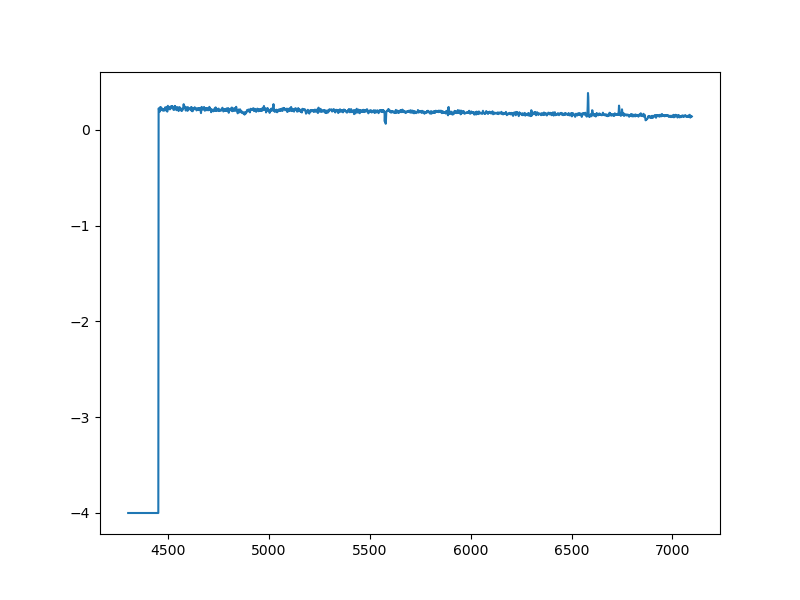

In [53]:
plt.figure(figsize = (8, 6))
plt.plot(wv, spectra[12])

In [51]:
4861.3*(1+z[11])

4874.785310240792